# 🔮 Prédiction de la Coupe du Monde 2026
Cette analyse utilise les données historiques de la Coupe du Monde (1930-2022) préparées par notre pipeline ETL pour entraîner un modèle de Machine Learning.
Nous utiliserons ce modèle pour évaluer les probabilités de victoire des 48 équipes qualifiées pour l'édition 2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette("viridis")

## 1. Chargement et Alignement des Données
Nous chargeons l'historique (`ml_dataset_historical.csv`) et les données de 2026 (`wc_prediction_features_2026.csv`).
Pour éviter les erreurs, nous n'utiliserons que les variables disponibles dans les deux jeux de données.

In [2]:
# Chargement des données d'entraînement (Historique)
train_df = pd.read_csv('../data/processed/ml_dataset_historical.csv')

# Chargement des données d'inférence (2026)
test_df = pd.read_csv('../data/raw/compets/wc_prediction_features_2026.csv')

# Sélection des features communes (X)
features = ['wc_appearances', 'wc_titles', 'elo_rating', 'host_nation', 'consecutive_wc_appearances', 'is_debut']

# Alignement des données 2026
test_df['host_nation'] = test_df['host_nation'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)
test_df['is_debut'] = test_df['is_debut'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)
test_df['elo_rating'] = test_df['elo_rating_2026']

X_train = train_df[features].fillna(0)
# La cible : 1 si l'équipe a atteint le dernier carré (Top 4), 0 sinon.
# Le Top 4 permet d'avoir plus de cas positifs (4 par édition) que le vainqueur seul.
y_train = train_df['target_top4']

X_test = test_df[features].fillna(0)
teams_2026 = test_df['team']

print(f"Taille du jeu d'entraînement : {X_train.shape}")
print(f"Taille du jeu de prédiction 2026 : {X_test.shape}")
display(X_train.head(3))

Taille du jeu d'entraînement : (193, 6)
Taille du jeu de prédiction 2026 : (48, 6)


,wc_appearances,wc_titles,elo_rating,host_nation,consecutive_wc_appearances,is_debut
0,0,0,1900.0,0,0,1
1,1,0,0.0,0,1,0
2,2,0,1830.0,0,2,0


## 2. Entraînement du Modèle (Random Forest)
Le Random Forest est un modèle ensembliste robuste. Il n'a pas besoin de normalisation des données et résiste bien au surapprentissage.

In [3]:
# Entraînement du modèle complet sur toute l'histoire
model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Évaluation simple sur le set d'entraînement (Attention au surapprentissage, mais donne une idée de l'ajustement)
y_pred = model.predict(X_train)
print("Précision sur l'historique:", accuracy_score(y_train, y_pred))
print(classification_report(y_train, y_pred))

Précision sur l'historique: 0.844559585492228
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       105
           1       0.81      0.86      0.84        88

    accuracy                           0.84       193
   macro avg       0.84      0.85      0.84       193
weighted avg       0.85      0.84      0.84       193



## 3. Interprétation du modèle (Feature Importance)
Qu'est-ce qui est le plus important pour atteindre le Top 4 ? Le classement ELO ? L'expérience ? Jouer à domicile ?

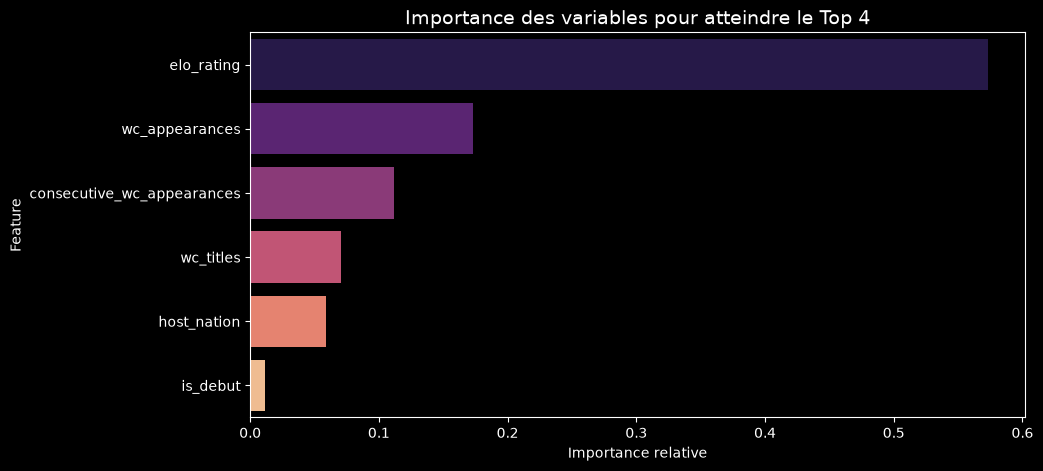

In [4]:
importances = model.feature_importances_
feature_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='magma')
plt.title('Importance des variables pour atteindre le Top 4', fontsize=14)
plt.xlabel('Importance relative')
plt.show()

## 4. Prédiction pour 2026
Qui a le plus de chances d'atteindre les demi-finales (Top 4) ou de gagner en 2026 selon notre modèle entraîné sur l'histoire ?

In [5]:
# Prédiction des probabilités pour 2026
proba = model.predict_proba(X_test)[:, 1] # Probabilité d'être de classe 1 (Top 4)

results = pd.DataFrame({
    'Équipe': teams_2026,
    'Confédération': test_df['confederation'],
    'Score ELO actuel': test_df['elo_rating'],
    'Probabilité Top 4 (%)': np.round(proba * 100, 1)
})

# Tri par probabilité décroissante
top_favorites = results.sort_values(by='Probabilité Top 4 (%)', ascending=False).reset_index(drop=True)
top_favorites.index += 1

# Export des prédictions
import os
os.makedirs('../data/processed', exist_ok=True)
top_favorites.to_csv('../data/processed/predictions_2026.csv', index=False)

# Affichage du Top 10
print("=== LES 10 FAVORIS POUR LA COUPE DU MONDE 2026 (Probabilité d'atteindre le Top 4) ===")
display(top_favorites.head(10))

=== LES 10 FAVORIS POUR LA COUPE DU MONDE 2026 (Probabilité d'atteindre le Top 4) ===


,Équipe,Confédération,Score ELO actuel,Probabilité Top 4 (%)
1,United States,CONCACAF,1820,76.2
2,Mexico,CONCACAF,1780,70.9
3,Spain,UEFA,1990,70.6
4,Portugal,UEFA,1940,66.0
5,Netherlands,UEFA,1940,65.4
6,France,UEFA,1990,64.9
7,Argentina,CONMEBOL,1980,64.9
8,Belgium,UEFA,1900,61.0
9,England,UEFA,1940,59.5
10,South Korea,AFC,1800,57.3
